# CO5420 Air Pollution Forecasting

## 05 — Temporal and Weather-Feature Ablation

## tl;dr

Meteorological features improved GRU validation RMSE at every
tested history length. The 24-hour all-feature configuration was
best (`16.1782` RMSE at seed 42), but the gain over 12 hours was
small. This supports retaining a full daily window while noting
the accuracy–compute trade-off.

## Context & Methods

Two questions are tested:

1. How much history is useful: 6, 12, or 24 hours?
2. Do meteorological inputs improve forecasting beyond pollution
   history?

The controlled grid uses the same GRU architecture, target
samples, chronological split, optimisation settings, batch size,
and seed 42.

The pollution-only feature set retains pollutant values,
pollutant missingness indicators, cyclical time features, and
station identity. It excludes temperature, pressure, dew point,
rain, wind speed, and wind direction.

### Key Assumptions

- Comparisons in the six-run grid use seed 42 only.
- Validation RMSE is the selection metric.
- The local-test period is not evaluated for rejected grid
  configurations.

## Data

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Metrics directory exists: {METRICS_DIR.exists()}")

Project root: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution
Metrics directory exists: True


In [2]:
ablation_results = pd.read_csv(
    METRICS_DIR / "temporal_ablation_results.csv"
)

grid = (
    ablation_results.loc[
        ablation_results["seed"].eq(42)
        & ablation_results["window_size"].isin([6, 12, 24])
        & ablation_results["feature_set"].isin(
            ["pollution_only", "all_features"]
        )
    ]
    .sort_values(["window_size", "feature_set"])
    .reset_index(drop=True)
)

assert len(grid) == 6
assert grid["local_test_rmse"].notna().sum() == 1
display(
    grid[
        [
            "window_size",
            "feature_set",
            "feature_count",
            "best_epoch",
            "training_seconds",
            "validation_rmse",
            "validation_mae",
        ]
    ]
)

,window_size,feature_set,feature_count,best_epoch,training_seconds,validation_rmse,validation_mae
0,6,all_features,43,16,121.8955,16.3545,8.6008
1,6,pollution_only,30,8,79.8676,17.2793,8.8706
2,12,all_features,43,12,92.4608,16.2914,8.6391
3,12,pollution_only,30,10,86.9677,17.2064,8.7221
4,24,all_features,43,19,140.7417,16.1782,8.5014
5,24,pollution_only,30,10,96.6376,17.0593,8.7153


## Results

In [3]:
rmse_pivot = grid.pivot(
    index="window_size",
    columns="feature_set",
    values="validation_rmse",
)

improvement = pd.DataFrame(
    {
        "pollution_only_rmse": rmse_pivot["pollution_only"],
        "all_features_rmse": rmse_pivot["all_features"],
    }
)
improvement["absolute_rmse_reduction"] = (
    improvement["pollution_only_rmse"]
    - improvement["all_features_rmse"]
)
improvement["relative_improvement_percent"] = (
    improvement["absolute_rmse_reduction"]
    / improvement["pollution_only_rmse"]
    * 100
)
display(improvement)

,pollution_only_rmse,all_features_rmse,absolute_rmse_reduction,relative_improvement_percent
window_size,,,,
6,17.2793,16.3545,0.9248,5.3521
12,17.2064,16.2914,0.9151,5.3181
24,17.0593,16.1782,0.8811,5.1648


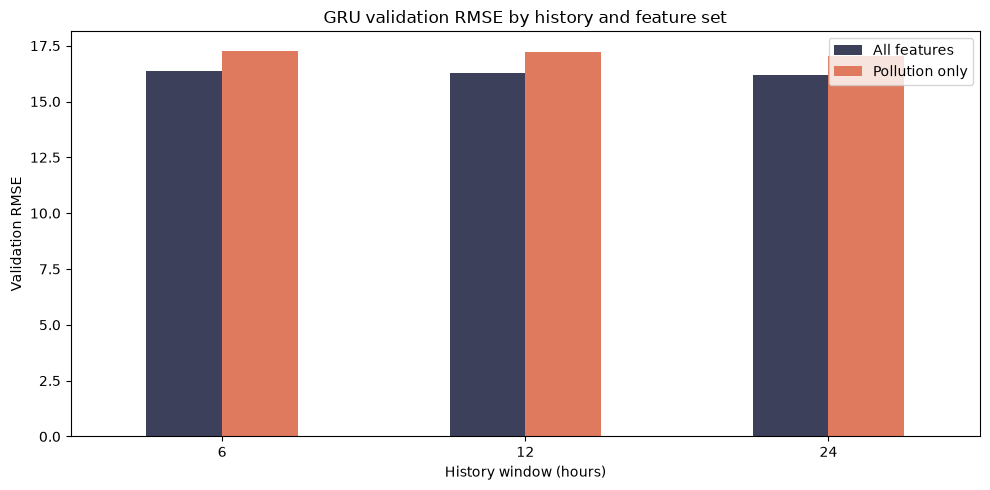

In [4]:
axis = rmse_pivot.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#3D405B", "#E07A5F"],
)
axis.set_title("GRU validation RMSE by history and feature set")
axis.set_xlabel("History window (hours)")
axis.set_ylabel("Validation RMSE")
axis.tick_params(axis="x", rotation=0)
axis.legend(["All features", "Pollution only"])
plt.tight_layout()
plt.show()

### Accuracy–compute trade-off

In [5]:
all_feature_tradeoff = (
    grid.loc[
        grid["feature_set"] == "all_features",
        [
            "window_size",
            "training_seconds",
            "validation_rmse",
            "validation_mae",
            "best_epoch",
        ],
    ]
    .sort_values("window_size")
    .reset_index(drop=True)
)
display(all_feature_tradeoff)

best = grid.loc[grid["validation_rmse"].idxmin()]
print(
    "Selected configuration:",
    f"{int(best['window_size'])}-hour",
    best["feature_set"],
    f"(validation RMSE {best['validation_rmse']:.4f})",
)

,window_size,training_seconds,validation_rmse,validation_mae,best_epoch
0,6,121.8955,16.3545,8.6008,16
1,12,92.4608,16.2914,8.6391,12
2,24,140.7417,16.1782,8.5014,19


Selected configuration: 24-hour all_features (validation RMSE 16.1782)


### Robustness of the selected configuration

In [6]:
selected_runs = ablation_results.loc[
    (ablation_results["window_size"] == 24)
    & (ablation_results["feature_set"] == "all_features")
].sort_values("seed")

robustness_summary = pd.DataFrame(
    {
        "metric": [
            "validation_rmse",
            "local_test_rmse",
        ],
        "mean": [
            selected_runs["validation_rmse"].mean(),
            selected_runs["local_test_rmse"].mean(),
        ],
        "sample_sd": [
            selected_runs["validation_rmse"].std(ddof=1),
            selected_runs["local_test_rmse"].std(ddof=1),
        ],
    }
)
display(selected_runs[
    [
        "seed",
        "validation_rmse",
        "validation_mae",
        "local_test_rmse",
        "local_test_mae",
    ]
])
display(robustness_summary)

,seed,validation_rmse,validation_mae,local_test_rmse,local_test_mae
4,42,16.1782,8.5014,27.2517,11.8266
5,123,15.9583,8.4340,26.7436,11.7825
6,2026,16.2768,8.4505,27.3588,11.8290


,metric,mean,sample_sd
0,validation_rmse,16.1378,0.1631
1,local_test_rmse,27.1180,0.3287


## Takeaways

- Weather information reduces validation RMSE by approximately
  5.2–5.4% at every tested history length.
- Longer windows improve both feature sets, but the incremental
  gain from 12 to 24 hours is small.
- The validation-selected recurrent configuration is a 24-hour
  all-feature GRU.
- The selected GRU is reasonably stable across seeds but remains
  weaker than the LSTM and feedforward network.
- Rejected configurations were not compared using local-test
  results, preserving the intended evaluation boundary.

Reproduce the grid:

```bash
conda activate co5420-air-gpu
python -m scripts.run_temporal_ablation \
  --grid \
  --model gru \
  --batch-size 512
```